## Single Feature Gradient Descent for Linear Regression

$$\hat{y} = w x + b$$

to data by learning two parameters: the **weight** $w$ (slope) and the **bias** $b$ (intercept). Instead of solving for them directly, we start from a guess and let **gradient descent** nudge $w$ and $b$ downhill on an error surface until the line fits.

In [146]:
import numpy as np

### The data

From the **California housing** dataset from scikit-learn (~20k neighborhoods), use the**`AveRooms`** — the average number of rooms per household and predict **`MedHouseVal`**, the median home value (in \$100,000s).


In [147]:
from sklearn.datasets import fetch_california_housing

# California housing; AveRooms (avg rooms/household) stands in for house "size"
homes = fetch_california_housing(as_frame=True).frame
homes = homes[(homes["AveRooms"] > 3) & (homes["AveRooms"] < 9)]   # drop outliers

size  = homes["AveRooms"].to_numpy()       # size proxy  (avg rooms)
price = homes["MedHouseVal"].to_numpy()    # median house value ($100k)

# standardize the feature so gradient descent stays stable
size_mu, size_sigma = size.mean(), size.std()
x = (size - size_mu) / size_sigma
y = price

print(f"{len(x)} homes | size {size.min():.1f}-{size.max():.1f} rooms | price ${price.min()*100:.0f}k-${price.max()*100:.0f}k")

19864 homes | size 3.0-9.0 rooms | price $15k-$500k


### The cost function

We measure how bad the current line is with **mean squared error** (MSE) over the $n$ data points:

$$J(w, b) = \frac{1}{2n} \sum_{i=1}^{n} \left( \hat{y}_i - y_i \right)^2$$

MSE is **convex** in $w$ and $b$, so the error surface is a single bowl — gradient descent is guaranteed to reach the global minimum, given a small enough learning rate.

In [148]:
# predicted data point y_hat
def prediction(w, xi, b):
    return w*xi + b


# MSE 
def cost(w, b, x, y):
    n = len(x)
    return np.sum((w*x + b - y)**2 / (2*n))


### The gradients

To know which direction minimizes cost, take the partial derivatives of $J$ with respect to each parameter. Let the error on point $i$ be $e_i = \hat{y}_i - y_i = (w x_i + b) - y_i$.

$$\frac{\partial J}{\partial w} = \frac{1}{n} \sum_{i=1}^{n} e_i \, x_i \qquad\qquad \frac{\partial J}{\partial b} = \frac{1}{n} \sum_{i=1}^{n} e_i$$

In [149]:
# calculate gradient of W at i 
def gradW(w, b, x, y):
    n = len(x)
    return np.sum(((w * x + b) - y) * x / n)

# calculate gradient of b
def gradB(w, b, x, y):
    n = len(x)
    return np.sum((w * x + b - y) / n)

**The training loop:**
1. Predict $\hat{y} = wx + b$ for all points.
2. Compute the errors $e = \hat{y} - y$.
3. Compute the two gradients.
4. Update $w$ and $b$.
5. Repeat for a fixed number of epochs (or until the cost stops decreasing).


In [150]:
# initialize variables
w = 0
b = 0
alpha = 0.1   # larger step is fine now that the feature is standardized

In [151]:
# Gradient Descent Algorithm w/ one feature

def gradient_descent(w, b):
    cost_history = []
    wb_history = []
    prev_J = float('inf')
    tol = 1e-9

    converged = False
    i = 0
    while not converged: 
        tmp_w = w - alpha * gradW(w, b, x, y)
        tmp_b = b - alpha * gradB(w, b, x, y)
        w = tmp_w
        b = tmp_b

        J = cost(w, b, x, y)
        cost_history.append(J)          
        wb_history.append((w, b))       

        if abs(prev_J - J) < tol:       # barely improving → stop
            converged = True
            print(f"converged at iter {i}, cost {J:.8f}")
        prev_J = J
        i += 1

    # w, b are in *standardized* feature units; np.polyfit(x, y, 1) should match.
    print(f"\nfinal: w = {w:.4f}, b = {b:.4f}  (least-squares fit = {np.polyfit(x, y, 1).round(4)})")
    return cost_history, wb_history

cost_history, wb_history = gradient_descent(w, b)

converged at iter 95, cost 0.58150334

final: w = 0.4021, b = 2.0679  (least-squares fit = [0.4021 2.068 ])


### Visualizing the cost surface

The cost $J(w, b)$ lives over a 2-D plane of parameters, and is linear, resulting in bowl shape. Should always converge to minima as long as alpha is chosen correctly.

In [152]:
import matplotlib.pyplot as plt

# Unpack the descent path recorded during training so we can plot it.
ws, bs = zip(*wb_history)        # w and b at every iteration
w_opt, b_opt = wb_history[-1]    # final (converged) parameters

### The fitted line

The learned line $\hat{y} = w x + b$ laid over the real price-vs-size scatter.

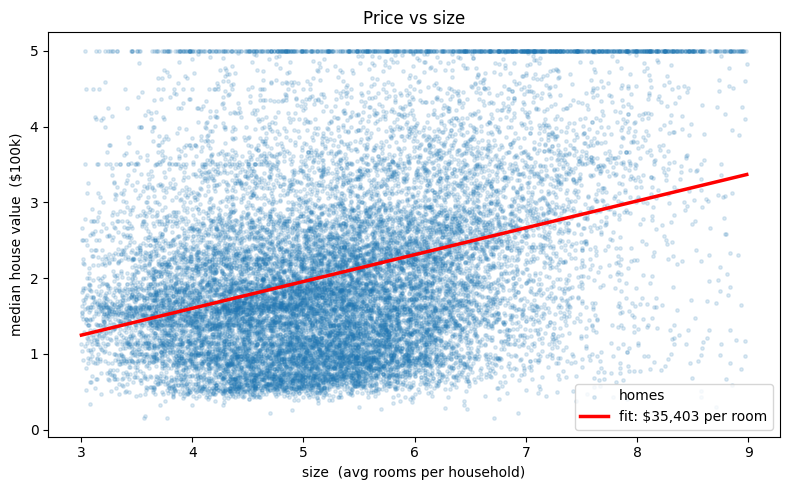

In [153]:
# Price vs size, with the fitted line overlaid.
# Plot in real units (rooms, $): map a size range through the same standardization.
size_line = np.linspace(size.min(), size.max(), 100)
x_line    = (size_line - size_mu) / size_sigma
price_line = w_opt * x_line + b_opt          # prediction in $100k

# slope back in real-world units: dollars per extra average room
dollars_per_room = w_opt / size_sigma * 100_000

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(size, price, s=6, alpha=0.15, c="tab:blue", label="homes")
ax.plot(size_line, price_line, c="red", lw=2.5,
        label=f"fit: ${dollars_per_room:,.0f} per room")
ax.set_xlabel("size  (avg rooms per household)")
ax.set_ylabel("median house value  ($100k)")
ax.set_title("Price vs size")
ax.legend()

plt.tight_layout()
plt.show()

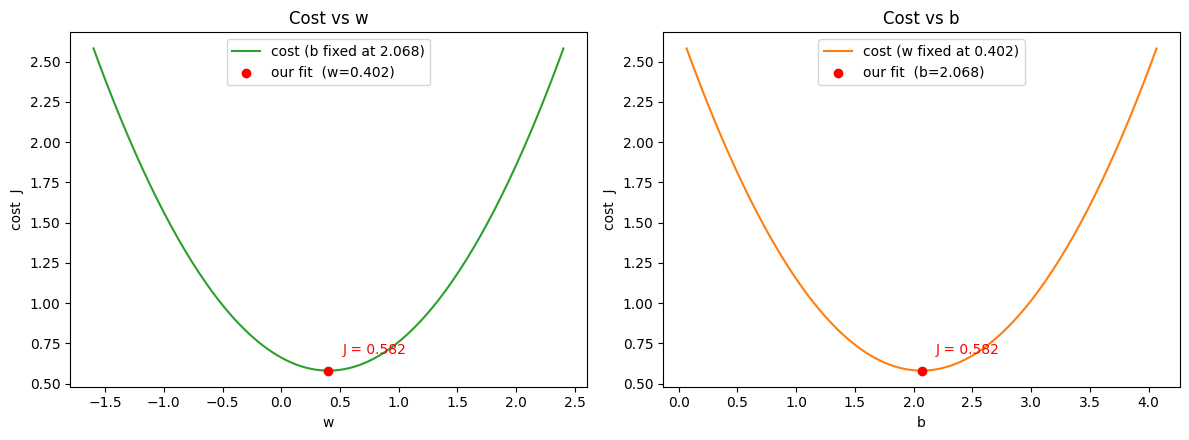

In [154]:
# cost as a function of each parameter (1-D slices through the cost bowl)
# For each slice we vary ONE parameter and hold the other fixed at its optimum,
# so we see the pure convex parabola — just the curve.

# --- slice 1: vary w, hold b = b_opt ---
w_grid = np.linspace(w_opt - 2.0, w_opt + 2.0, 200)
J_vs_w = [cost(wi, b_opt, x, y) for wi in w_grid]

# --- slice 2: vary b, hold w = w_opt ---
b_grid = np.linspace(b_opt - 2.0, b_opt + 2.0, 200)
J_vs_b = [cost(w_opt, bi, x, y) for bi in b_grid]

J_here = cost(w_opt, b_opt, x, y)   # cost at our learned (w, b) — where our prediction sits

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

# cost vs w
ax1.plot(w_grid, J_vs_w, c="tab:green", label=f"cost (b fixed at {b_opt:.3f})")
ax1.scatter([w_opt], [J_here], c="red", zorder=5, label=f"our fit  (w={w_opt:.3f})")
ax1.annotate(f"J = {J_here:.3f}", (w_opt, J_here),
             textcoords="offset points", xytext=(10, 12), color="red")
ax1.set_xlabel("w")
ax1.set_ylabel("cost  J")
ax1.set_title("Cost vs w")
ax1.legend()

# cost vs b
ax2.plot(b_grid, J_vs_b, c="tab:orange", label=f"cost (w fixed at {w_opt:.3f})")
ax2.scatter([b_opt], [J_here], c="red", zorder=5, label=f"our fit  (b={b_opt:.3f})")
ax2.annotate(f"J = {J_here:.3f}", (b_opt, J_here),
             textcoords="offset points", xytext=(10, 12), color="red")
ax2.set_xlabel("b")
ax2.set_ylabel("cost  J")
ax2.set_title("Cost vs b")
ax2.legend()

plt.tight_layout()
plt.show()

Tthe red dot lands at the bottom of both parabolas the predicted w and b each sit at the minimum of their slice.

### The gradient field

The gradient $\nabla J = \left(\dfrac{\partial J}{\partial w},\ \dfrac{\partial J}{\partial b}\right)$ is a **vector** at every point in the $(w, b)$ plane, pointing in the direction of steepest *increase* in cost. Gradient descent steps the opposite way, $-\nabla J$.

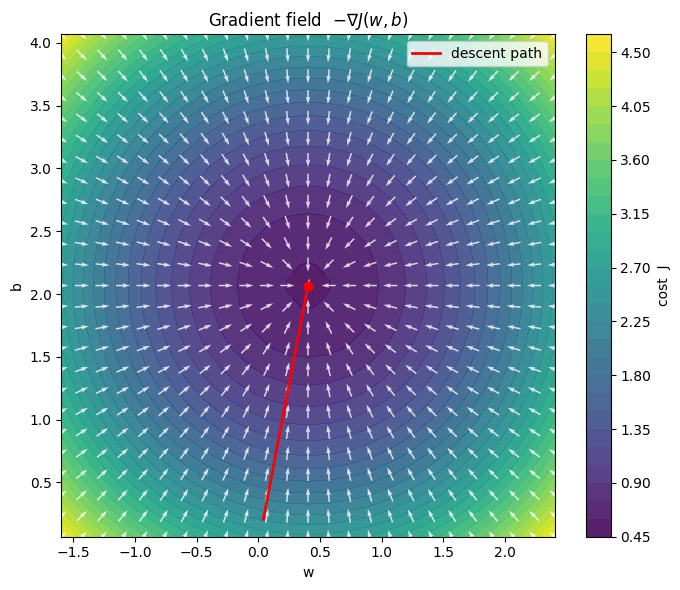

In [155]:
# Gradient field of the cost over the (w, b) plane.

# grid of parameter values around the optimum
W, B = np.meshgrid(
    np.linspace(w_opt - 2.0, w_opt + 2.0, 25),
    np.linspace(b_opt - 2.0, b_opt + 2.0, 25),
)

# cost and gradient at every grid point
J  = np.vectorize(lambda wij, bij: cost(wij, bij, x, y))(W, B)
dW = np.vectorize(lambda wij, bij: gradW(wij, bij, x, y))(W, B)
dB = np.vectorize(lambda wij, bij: gradB(wij, bij, x, y))(W, B)

fig, ax = plt.subplots(figsize=(7, 6))

# cost bowl as filled contours
cf = ax.contourf(W, B, J, levels=30, cmap="viridis", alpha=0.9)
fig.colorbar(cf, ax=ax, label="cost  J")

# arrows point downhill (-gradient); normalize so we see direction, not magnitude
mag = np.hypot(dW, dB) + 1e-12
ax.quiver(W, B, -dW / mag, -dB / mag, color="white",
          pivot="mid", scale=35, width=0.003, alpha=0.8)

# overlay the actual descent path
ax.plot(ws, bs, c="red", lw=2, label="descent path")
ax.scatter([w_opt], [b_opt], c="red", s=40, zorder=5)

ax.set_xlabel("w")
ax.set_ylabel("b")
ax.set_title(r"Gradient field  $-\nabla J(w, b)$")
ax.legend(loc="upper right")

plt.tight_layout()
plt.show()

### The cost surface in 3-D

The 1-D slices and the gradient field are both flattened views of the same object: the full cost **surface** $J(w, b)$. In 3-D it's a smooth convex bowl. Gradient descent starts up on the wall and rolls down to the single lowest point — the red curve traces that descent.

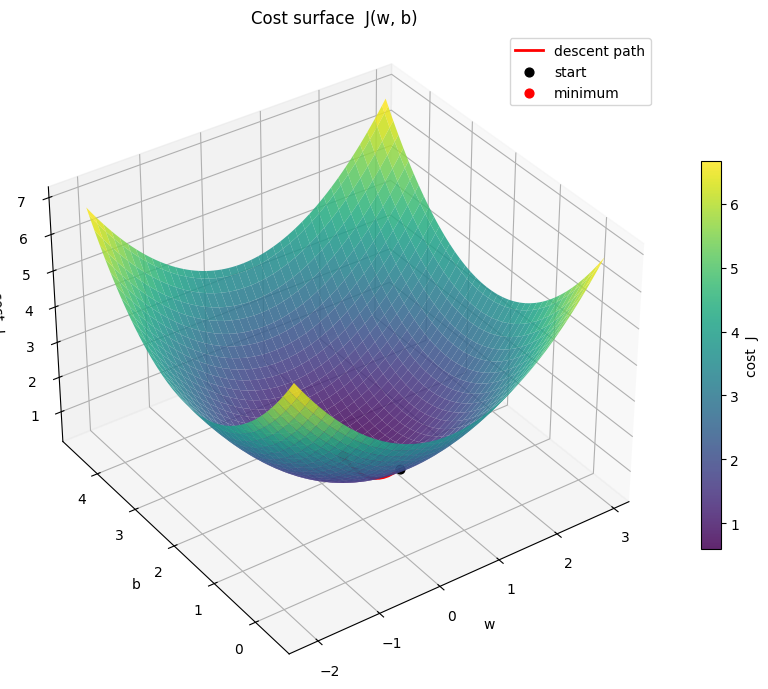

In [156]:
# 3-D surface of the cost function J(w, b)

# a smooth grid over the (w, b) plane
Ws, Bs = np.meshgrid(
    np.linspace(w_opt - 2.5, w_opt + 2.5, 80),
    np.linspace(b_opt - 2.5, b_opt + 2.5, 80),
)
Js = np.vectorize(lambda wij, bij: cost(wij, bij, x, y))(Ws, Bs)

# cost along the actual descent path (z-value for each recorded step)
path_J = np.array(cost_history)

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")

# the bowl
surf = ax.plot_surface(Ws, Bs, Js, cmap="viridis", alpha=0.85,
                       linewidth=0, antialiased=True)
fig.colorbar(surf, ax=ax, shrink=0.6, label="cost  J")

# the descent path riding down the surface
ax.plot(ws, bs, path_J, c="red", lw=2, label="descent path")
ax.scatter([ws[0]], [bs[0]], [path_J[0]], c="black", s=40, label="start")
ax.scatter([w_opt], [b_opt], [path_J[-1]], c="red", s=40, label="minimum")

ax.set_xlabel("w")
ax.set_ylabel("b")
ax.set_zlabel("cost  J")
ax.set_title("Cost surface  J(w, b)")
ax.view_init(elev=35, azim=-125)   # camera angle
ax.legend()

plt.tight_layout()
plt.show()

### Takeaways

In a single feature gradient descent and using a **Squared Error Cost Function**, the shape of the cost function will always have a single global minimum due to the **Convex Function** Shape, as long as alpha is chosen appropriately.
